<a href="https://colab.research.google.com/github/SanjayGanapathy/AETHER/blob/main/AETHER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AETHER**: an **A**nomaly **E**nsemble Framework for **T**rajectory **H**euristics & **E**xplainable **R**easoning

Migratory Ecology of the Common Kestrel (*Falco tinnunculus*)  
### Data‑Quality Assessment & Spatial Analysis  
*Author: Sanjay Ganapathy*


In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")
display(df.head())
display(df.info())

/tmp/ipython-input-6-251111154.py:3: DtypeWarning: Columns (15,18,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data.csv")


,event-id,visible,timestamp,location-long,location-lat,gps:activity-count,external-temperature,gps:dop,gps:hdop,gps:satellite-count,...,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name,utm-easting,utm-northing,utm-zone,study-timezone,study-local-timestamp
0,29615547747,True,2023-04-28 10:06:54.000,-6.470255,37.427571,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723839.343781,4.145310e+06,29N,GMT+00:00,2023-04-28 10:06:54.000
1,29615547748,True,2023-04-28 10:26:55.000,-6.477722,37.429683,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723172.271891,4.145527e+06,29N,GMT+00:00,2023-04-28 10:26:55.000
2,29615547749,True,2023-04-28 10:28:55.000,-6.478029,37.429824,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723144.667806,4.145542e+06,29N,GMT+00:00,2023-04-28 10:28:55.000
3,29615547750,True,2023-04-28 10:31:10.000,-6.477894,37.429808,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723156.609110,4.145540e+06,29N,GMT+00:00,2023-04-28 10:31:10.000
4,29615547751,True,2023-04-28 10:32:54.000,-6.477960,37.429709,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723151.098516,4.145529e+06,29N,GMT+00:00,2023-04-28 10:32:54.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2534898 entries, 0 to 2534897
Data columns (total 30 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   event-id                         int64  
 1   visible                          bool   
 2   timestamp                        object 
 3   location-long                    float64
 4   location-lat                     float64
 5   gps:activity-count               float64
 6   external-temperature             float64
 7   gps:dop                          float64
 8   gps:hdop                         float64
 9   gps:satellite-count              float64
 10  gps-time-to-fix                  float64
 11  ground-speed                     float64
 12  heading                          float64
 13  height-above-msl                 float64
 14  height-raw                       float64
 15  import-marked-outlier            object 
 16  gls:light-level                  float64
 17  location

None

In [ ]:
required_columns = ['location-lat', 'location-long']
if all(col in df.columns for col in required_columns):
    print(f"Columns '{required_columns[0]}' and '{required_columns[1]}' exist in the DataFrame.")
    print(f"Initial number of rows: {len(df)}")

    df.dropna(subset=required_columns, inplace=True)
    print(f"Number of rows after dropping missing lat/long: {len(df)}")

    if 'timestamp' in df.columns:
        df.dropna(subset=['timestamp'], inplace=True)
        print(f"Number of rows after dropping missing timestamp: {len(df)}")
    else:
        print("Warning: 'timestamp' column not found.")

    display(df.head())

else:
    print(f"Error: Required columns '{required_columns[0]}' and/or '{required_columns[1]}' not found in the DataFrame.")

Columns 'location-lat' and 'location-long' exist in the DataFrame.
Initial number of rows: 2534898
Number of rows after dropping missing lat/long: 2534898
Number of rows after dropping missing timestamp: 2534898


,event-id,visible,timestamp,location-long,location-lat,gps:activity-count,external-temperature,gps:dop,gps:hdop,gps:satellite-count,...,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name,utm-easting,utm-northing,utm-zone,study-timezone,study-local-timestamp
0,29615547747,True,2023-04-28 10:06:54.000,-6.470255,37.427571,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723839.343781,4.145310e+06,29N,GMT+00:00,2023-04-28 10:06:54.000
1,29615547748,True,2023-04-28 10:26:55.000,-6.477722,37.429683,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723172.271891,4.145527e+06,29N,GMT+00:00,2023-04-28 10:26:55.000
2,29615547749,True,2023-04-28 10:28:55.000,-6.478029,37.429824,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723144.667806,4.145542e+06,29N,GMT+00:00,2023-04-28 10:28:55.000
3,29615547750,True,2023-04-28 10:31:10.000,-6.477894,37.429808,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723156.609110,4.145540e+06,29N,GMT+00:00,2023-04-28 10:31:10.000
4,29615547751,True,2023-04-28 10:32:54.000,-6.477960,37.429709,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723151.098516,4.145529e+06,29N,GMT+00:00,2023-04-28 10:32:54.000


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 52.2 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Do

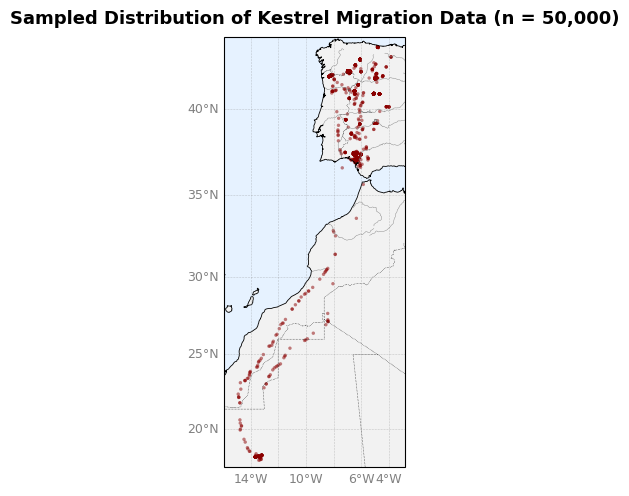

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Sample the data
sample_df = df.sample(n=50000, random_state=55)
lats = sample_df['location-lat'].values
lons = sample_df['location-long'].values

# Create a wider landscape figure while keeping height
fig = plt.figure(figsize=(16, 5))  # wider
ax = plt.axes(projection=ccrs.Mercator())

# Tighter extent with context (Europe/Africa)
lat_margin = 0.5
lon_margin = 1.0
ax.set_extent([
    lons.min() - lon_margin,
    lons.max() + lon_margin,
    lats.min() - lat_margin,
    lats.max() + lat_margin
], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.LAND, facecolor='#f2f2f2')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)
ax.add_feature(cfeature.RIVERS, linewidth=0.3, edgecolor='gray')
ax.add_feature(cfeature.LAKES, facecolor='#e6f2ff', edgecolor='gray', linewidth=0.3)

# Graticules
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.4, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'color': 'gray'}
gl.ylabel_style = {'size': 9, 'color': 'gray'}
gl.xpadding = 4
gl.ypadding = 4

# Plot points
ax.scatter(
    lons, lats,
    color='darkred',
    s=6,
    alpha=0.5,
    edgecolor='none',
    transform=ccrs.PlateCarree(),
    rasterized=True  # Helps vector export with large n
)

# Title only — legend optional
plt.title("Sampled Distribution of Kestrel Migration Data (n = 50,000)", fontsize=13, weight='bold', pad=10)

# Tight layout
plt.subplots_adjust(left=0.01, right=0.99, top=0.93, bottom=0.07)
plt.savefig("kestrel_map_expanded_horizontal.png", dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
print(f"Total number of data points in the dataset: {len(df)}")

Total number of data points in the dataset: 2534898


In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Number of birds: {df['individual-local-identifier'].nunique()}")

Number of rows: 2534898
Number of columns: 30
Number of birds: 61


In [ ]:
import numpy as np
import pandas as pd

def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance in kilometers between two points
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

# Convert 'timestamp' to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by bird and time
df.sort_values(['individual-local-identifier', 'timestamp'], inplace=True)

# Calculate time difference
df['time_diff'] = df.groupby('individual-local-identifier')['timestamp'].diff().dt.total_seconds() / 3600  # in hours

# Calculate distance
df['lat_prev'] = df.groupby('individual-local-identifier')['location-lat'].shift(1)
df['lon_prev'] = df.groupby('individual-local-identifier')['location-long'].shift(1)
df['distance_km'] = haversine(df['lon_prev'], df['lat_prev'], df['location-long'], df['location-lat'])

# Calculate speed
df['speed_kmh'] = df['distance_km'] / df['time_diff']

# Display the new columns
display(df[['individual-local-identifier', 'timestamp', 'time_diff', 'distance_km', 'speed_kmh']].head())

,individual-local-identifier,timestamp,time_diff,distance_km,speed_kmh
55450,5160275,2023-05-12 06:48:38,NaN,NaN,NaN
55451,5160275,2023-05-12 06:50:39,0.033611,0.014909,0.443581
55452,5160275,2023-05-12 06:52:39,0.033333,0.011988,0.359640
55453,5160275,2023-05-12 06:55:01,0.039444,0.010282,0.260682
55454,5160275,2023-05-12 06:56:33,0.025556,0.012815,0.501438


In [ ]:
# Summary statistics for the new columns
display(df[['time_diff', 'distance_km', 'speed_kmh']].describe())

,time_diff,distance_km,speed_kmh
count,2.534837e+06,2.534837e+06,2.534837e+06
mean,1.389082e-01,1.106872e-01,2.687551e+00
std,1.721234e+00,9.658986e+00,8.408660e+01
min,2.777778e-04,0.000000e+00,0.000000e+00
25%,5.000000e-03,3.228672e-03,1.468848e-01
50%,1.388889e-02,8.140389e-03,4.753092e-01
75%,4.944444e-02,4.147696e-02,1.591390e+00
max,9.428903e+02,6.477847e+03,1.035648e+05


Data points per bird:


,count
individual-local-identifier,
MX4477,281823
MX4659,278535
MX5892,243103
M15219,162594
MX4476,157601
...,...
MX9211,1484
MX4447,1076
MX9208,490


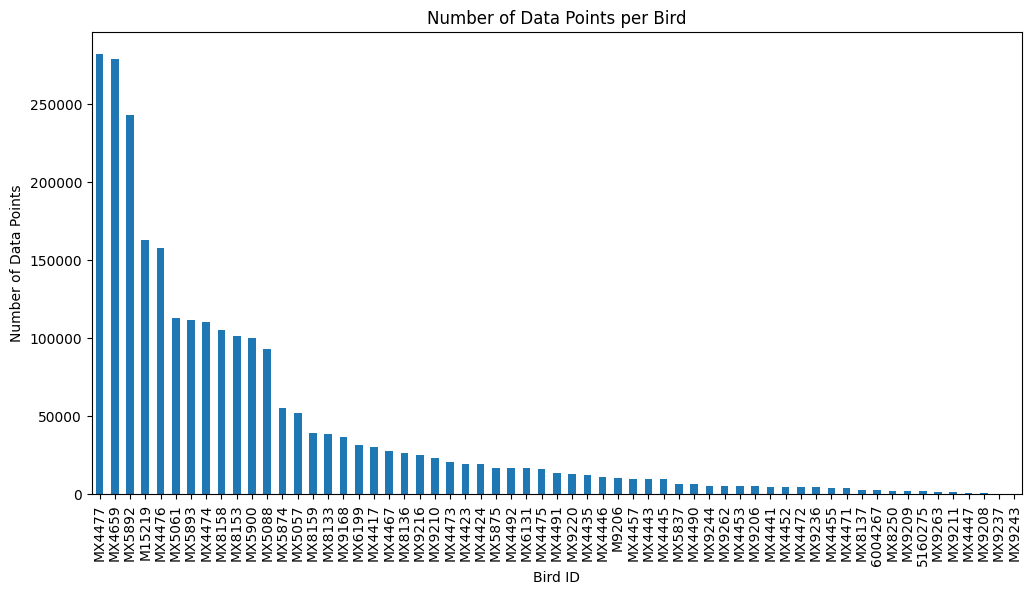

In [ ]:
# Analyze data points per bird
bird_counts = df['individual-local-identifier'].value_counts()
print("Data points per bird:")
display(bird_counts)

plt.figure(figsize=(12, 6))
bird_counts.plot(kind='bar')
plt.title('Number of Data Points per Bird')
plt.xlabel('Bird ID')
plt.ylabel('Number of Data Points')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Check for and remove duplicate rows
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(df)} duplicate rows.")

Removed 0 duplicate rows.


--- Library installation complete ---
All libraries imported successfully.

--- Section 1: Data Loading & Feature Engineering ---
Successfully loaded data.csv with 2534898 rows.
Feature engineering complete.

--- Section 2: Defining Expert Feature Sets ---

--- Section 3: Training the Expert Committee ---
Training Kinematic Expert...
Training Gps Expert...
Training Sequential Expert...

--- Section 4: Generating Specialized Scores on Real Data ---
All experts trained and scores calculated.

--- Section 5: Rigorous Quantitative Benchmarking ---
Unsupervised baseline (Isolation Forest) trained.
Semi-Supervised baseline (One-Class SVM) trained.

--- Final Benchmark Performance Summary ---
                              PR-AUC AUC-ROC Median Rank
Model                                                   
Kinematic Expert              0.0001  0.6870     574,148
GPS Expert                    0.5124  0.9976          52
Sequential Expert             0.0000  0.5000   1,226,760
Baseline ISO (vs Kin

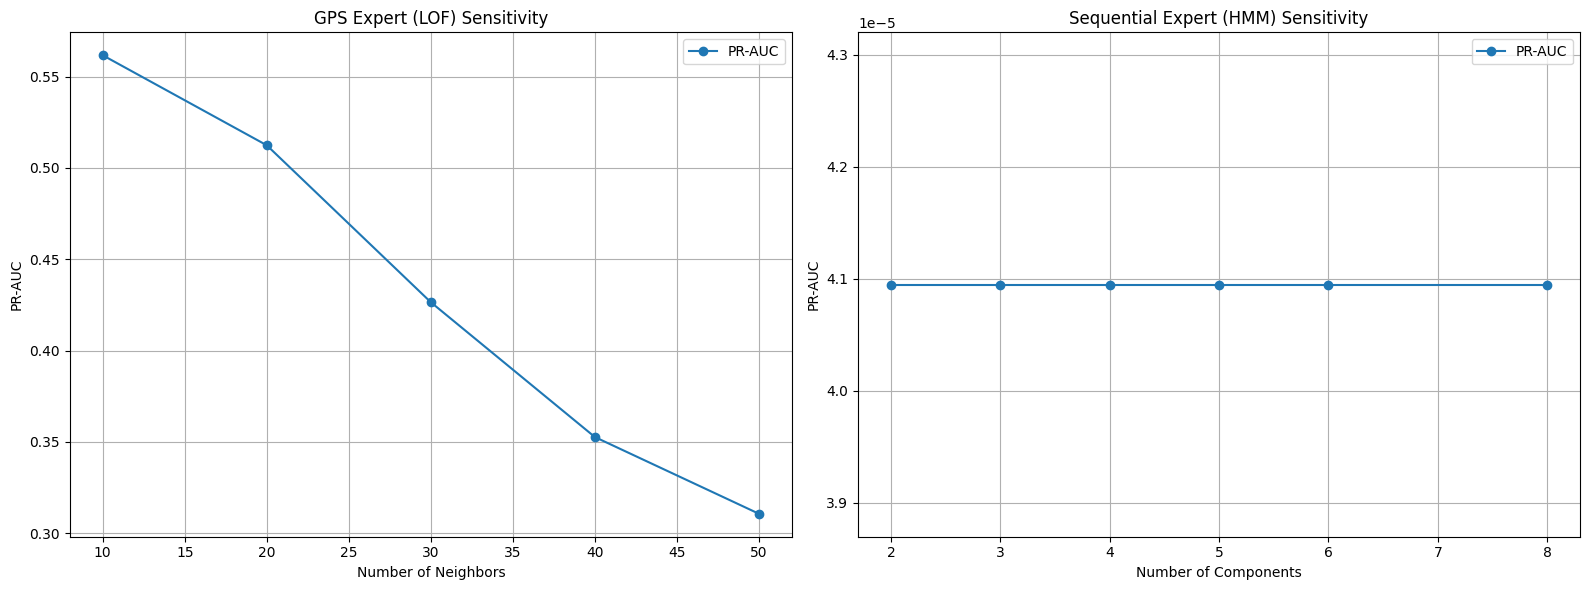


--- Section 7: Qualitative Case Study Analysis ---
Top anomaly for KINEMATIC expert found at index 2303833.
Top anomaly for GPS expert found at index 2218960.
Top anomaly for SEQUENTIAL expert found at index 1138639.


--- Section 8: Explaining Top 3 Anomalies with XAI ---

--- Explaining KINEMATIC Expert ---


  0%|          | 0/3 [00:00<?, ?it/s]

Explanation for kinematic anomaly #1 (Index: 2303833):


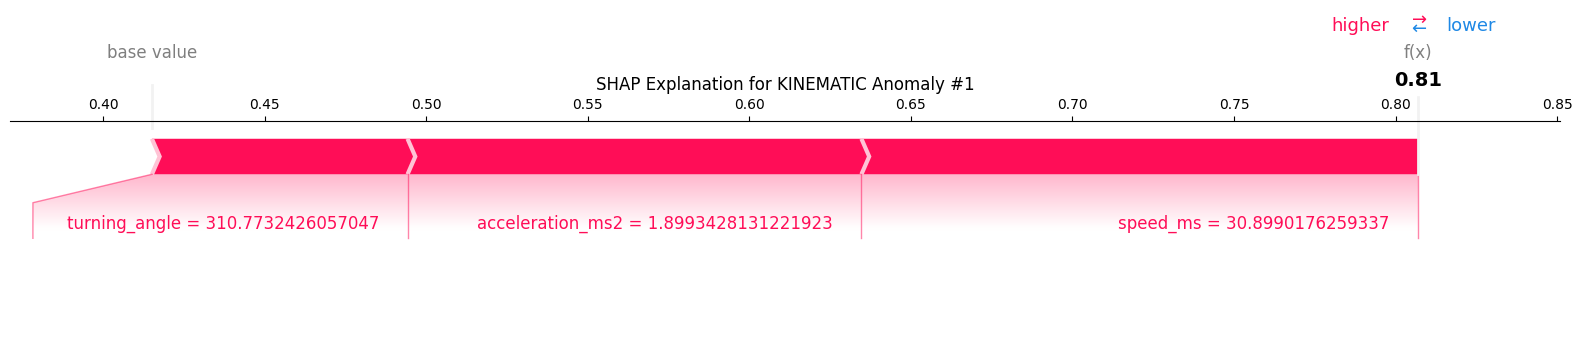

Explanation for kinematic anomaly #2 (Index: 2346068):


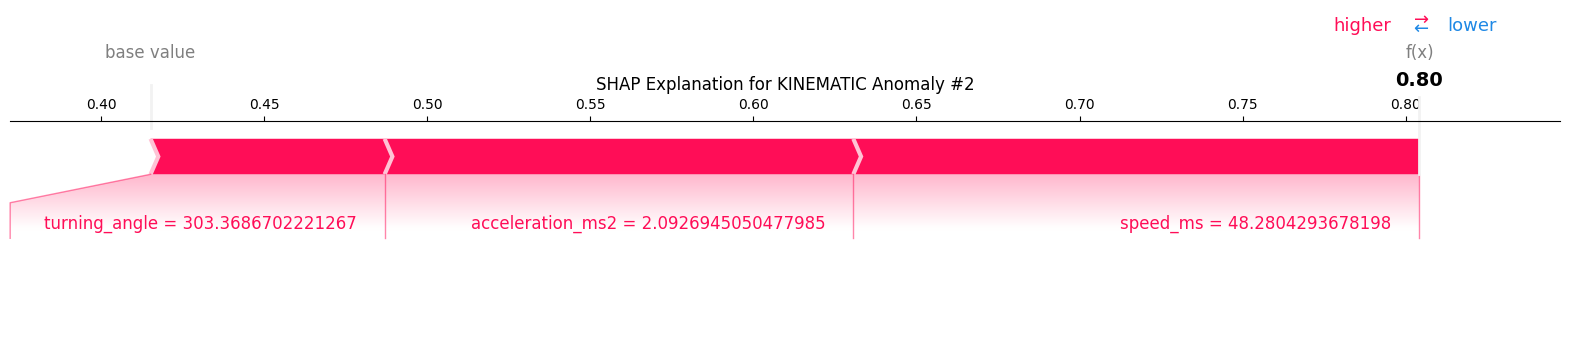

Explanation for kinematic anomaly #3 (Index: 1993219):


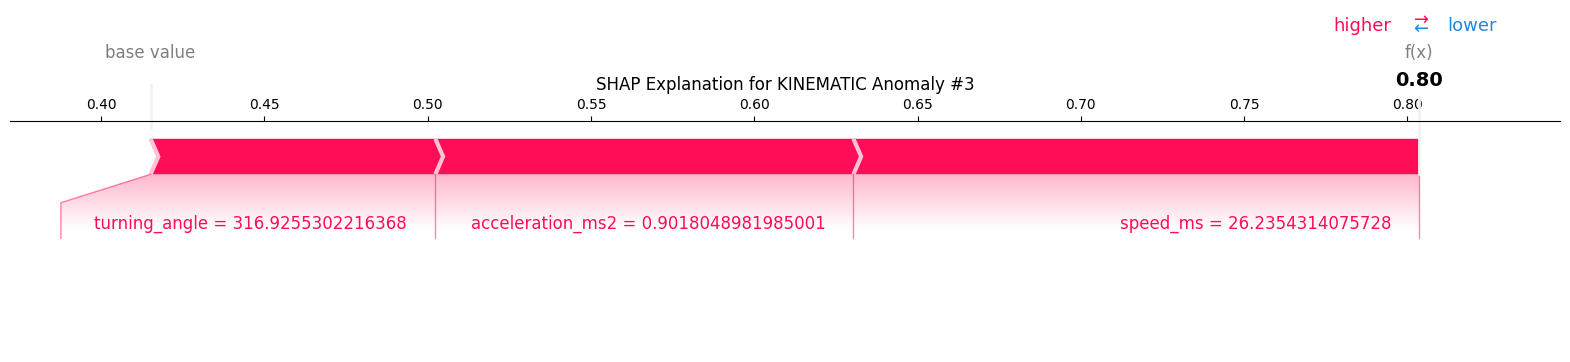


--- Explaining GPS Expert ---


  0%|          | 0/3 [00:00<?, ?it/s]

Explanation for gps anomaly #1 (Index: 2218960):


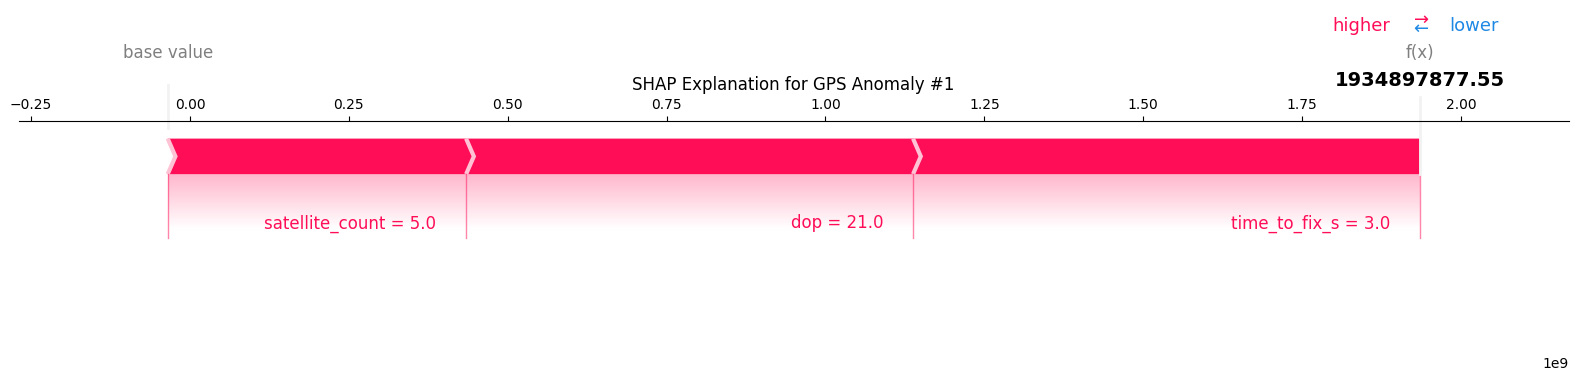

Explanation for gps anomaly #2 (Index: 1168810):


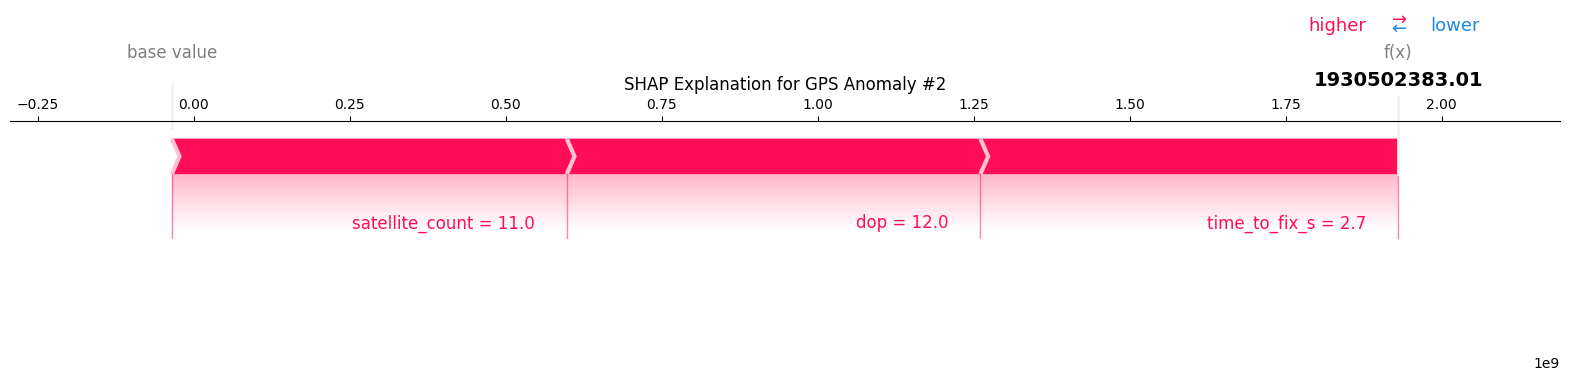

Explanation for gps anomaly #3 (Index: 2211669):


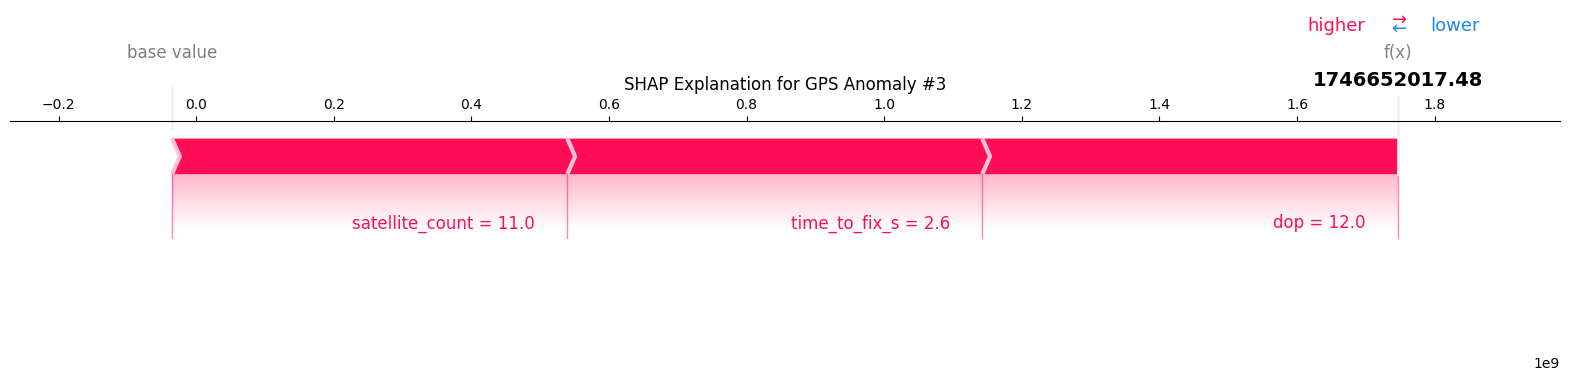


--- Explaining SEQUENTIAL Expert (HMM) ---
The Sequential (HMM) model learned the following behavioral states:
These are the average (scaled) feature values that characterize each hidden state.
             speed_ms  acceleration_ms2  turning_angle  satellite_count   dop  time_to_fix_s  heading  altitude_m
state_label                                                                                                      
State 0          1.24              0.01           0.40             0.14 -0.05          -0.17    -0.07        0.74
State 1         -0.23             -0.00          -0.59            -0.42  0.21          -0.22     0.22       -0.13
State 2         -0.35             -0.00           0.06             0.75 -0.69          -0.27    -0.09       -0.16
State 3         -0.24             -0.00           0.57            -0.74  0.93           1.09    -0.18       -0.25

Anomalies in the HMM are sequences with a low probability, often involving unlikely transitions between these states.

-

In [ ]:
# =============================================================================
# AETHER Framework for Google Colab - Single Cell Execution
#
# INSTRUCTIONS:
# 1. Upload your "data.csv" file to the Colab session storage.
#    (Click the folder icon on the left sidebar, then click the "Upload" icon).
# 2. Run this entire cell.
#
# This version includes a One-Class SVM (a semi-supervised model) as an
# additional baseline to address reviewer feedback.
# =============================================================================

# Step 1: Install required libraries
!pip install hmmlearn shap

print("--- Library installation complete ---")

# Step 2: Import all required libraries
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from hmmlearn.hmm import GaussianHMM
from sklearn.svm import OneClassSVM # <-- NEW: Import for semi-supervised model
from sklearn.metrics import roc_curve, auc, average_precision_score
import matplotlib.pyplot as plt
import shap
import os

print("All libraries imported successfully.")

# =============================================================================
# AETHER Framework Functions
# =============================================================================

def preprocess_movement_data(filepath):
    """
    Loads, cleans, and engineers features for movement data.
    This standardized function ensures a reproducible data pipeline.
    """
    print("\n--- Section 1: Data Loading & Feature Engineering ---")
    if not os.path.exists(filepath):
        print(f"ERROR: The file '{filepath}' was not found.")
        print("Please make sure you have uploaded 'data.csv' to your Colab session.")
        return None
    try:
        # Load data with specified types to handle mixed-type columns
        dtype_spec = {15: str, 18: str, 22: str}
        df = pd.read_csv(filepath, dtype=dtype_spec, low_memory=False)
        print(f"Successfully loaded {filepath} with {len(df)} rows.")

        # Define a mapping for renaming columns for consistency and clarity
        rename_map = {
            "tag-local-identifier": "animal_id",
            "timestamp": "timestamp",
            "location-long": "longitude",
            "location-lat": "latitude",
            "ground-speed": "speed_ms",
            "heading": "heading",
            "height-above-msl": "altitude_m",
            "gps:satellite-count": "satellite_count",
            "gps-time-to-fix": "time_to_fix_s",
            "gps:dop": "dop", # Dilution of Precision - a key GPS error metric
        }
        existing_cols = {k: v for k, v in rename_map.items() if k in df.columns}
        gdf = df[list(existing_cols.keys())].rename(columns=existing_cols)

        # Convert types, handle missing data, and create GeoDataFrame
        gdf["timestamp"] = pd.to_datetime(gdf["timestamp"])
        gdf = gdf.sort_values(by=["animal_id", "timestamp"]).drop_duplicates(
            subset=["animal_id", "timestamp"], keep="first"
        )
        numeric_cols = gdf.select_dtypes(include=np.number).columns
        # Interpolate missing values, then back-fill/forward-fill for robustness
        gdf[numeric_cols] = gdf.groupby("animal_id")[numeric_cols].transform(
            lambda x: x.interpolate(method="linear").bfill().ffill()
        )
        gdf.dropna(inplace=True)

        # Convert to GeoDataFrame with the correct Coordinate Reference System (CRS)
        gdf = gpd.GeoDataFrame(
            gdf,
            geometry=gpd.points_from_xy(gdf.longitude, gdf.latitude),
            crs="EPSG:4326" # WGS 84 - Standard for GPS data
        )

        #  Advanced Feature Engineering - deriving behavioral metrics
        gdf["time_diff_s"] = (
            gdf.groupby("animal_id")["timestamp"]
            .diff()
            .dt.total_seconds()
            .clip(lower=1e-6) # Avoid division by zero
        )
        gdf["acceleration_ms2"] = (
            gdf.groupby("animal_id")["speed_ms"].diff() / gdf["time_diff_s"]
        )
        gdf["turning_angle"] = gdf.groupby("animal_id")["heading"].diff().abs()
        gdf.fillna(0, inplace=True)
        print("Feature engineering complete.")
        return gdf

    except Exception as e:
        print(f"Data loading or feature engineering failed: {e}")
        return None

def train_experts(gdf, models, features_kinematic, features_gps, features_sequential):
    """
    Trains the expert committee models and calculates anomaly scores.
    """
    print("\n--- Section 3: Training the Expert Committee ---")

    scalers = {
        "kinematic": StandardScaler(),
        "gps": StandardScaler(),
        "sequential": StandardScaler(),
    }
    X_data = {
        "kinematic": gdf[features_kinematic],
        "gps": gdf[features_gps],
        "sequential": gdf[features_sequential],
    }
    X_scaled = {key: scalers[key].fit_transform(X_data[key]) for key in X_data}

    for name, model in models.items():
        print(f"Training {name.capitalize()} Expert...")
        model.fit(X_scaled[name])

    print("\n--- Section 4: Generating Specialized Scores on Real Data ---")
    for name, model in models.items():
        score_col = f"{name}_score"
        if name != "sequential":
            gdf[score_col] = (
                -model.score_samples(X_scaled[name])
                if isinstance(model, IsolationForest)
                else -model.decision_function(X_scaled[name])
            )
        else:
            # For HMM, we score sequences. Here we simplify to point-wise log probability density
            log_prob, _ = model.score_samples(X_scaled[name])
            gdf[score_col] = -log_prob

        cleaned_scores = (
            gdf[score_col]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(gdf[score_col].max())
        )
        min_val, max_val = cleaned_scores.min(), cleaned_scores.max()
        gdf[score_col] = (
            (cleaned_scores - min_val) / (max_val - min_val)
            if max_val > min_val
            else 0.5
        )

    print("All experts trained and scores calculated.")
    return gdf, models, scalers

def inject_anomalies(df, anomaly_type, n_anomalies=100, random_seed=55):
    """Injects a specific type of anomaly for targeted evaluation."""
    np.random.seed(random_seed)
    df_injected = df.copy()
    df_injected["is_anomaly"] = 0
    # Ensure indices are valid for sequential anomaly injection (idx-1, idx, idx+1)
    valid_indices = df_injected.index[df_injected.groupby("animal_id").cumcount().between(2, len(df_injected) - 3)]
    if len(valid_indices) < n_anomalies:
        n_anomalies = len(valid_indices)
        print(f"Warning: Not enough valid indices to inject anomalies. Injecting {n_anomalies} instead.")

    anomaly_indices = np.random.choice(valid_indices, size=n_anomalies, replace=False)

    for idx in anomaly_indices:
        if anomaly_type == "kinematic":
            df_injected.loc[idx, "speed_ms"] *= np.random.uniform(3.0, 5.0)
            df_injected.loc[idx, "is_anomaly"] = 1
        elif anomaly_type == "gps":
            df_injected.loc[idx, "satellite_count"] = np.random.randint(1, 4)
            df_injected.loc[idx, "is_anomaly"] = 1
        elif anomaly_type == "sequential":
            # Create a sharp, unrealistic change in behavior
            df_injected.loc[idx - 1, "speed_ms"] = 20
            df_injected.loc[idx, "speed_ms"] = 0
            df_injected.loc[idx + 1, "speed_ms"] = 20
            df_injected.loc[idx, "is_anomaly"] = 1
    return df_injected

def evaluate_model(model_name, model, scaler, features, gdf, anomaly_type_to_inject):
    """Runs a full benchmark evaluation for a single model and returns metrics."""
    gdf_benchmark = inject_anomalies(gdf, anomaly_type=anomaly_type_to_inject, n_anomalies=100)
    X_benchmark = gdf_benchmark[features]
    y_true = gdf_benchmark["is_anomaly"]
    X_benchmark_scaled = scaler.transform(X_benchmark)

    if "sequential" not in model_name.lower():
        y_scores_array = (
            -model.score_samples(X_benchmark_scaled)
            if isinstance(model, IsolationForest)
            else -model.decision_function(X_benchmark_scaled)
        )
        y_scores = pd.Series(y_scores_array, index=gdf_benchmark.index)
    else: # Handle HMM scoring
        log_prob, _ = model.score_samples(X_benchmark_scaled)
        y_scores = pd.Series(-log_prob, index=gdf_benchmark.index)

    # Handle cases where scores might be NaN or Inf
    y_scores.replace([np.inf, -np.inf], np.nan, inplace=True)
    y_scores.fillna(y_scores.min() - 1, inplace=True)

    ranks = (
        pd.DataFrame({"score": y_scores, "is_anomaly": y_true})
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
        .query("is_anomaly == 1")
        .index
    )

    # Calculate metrics
    pr_auc = average_precision_score(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    median_rank = np.median(ranks) if len(ranks) > 0 else np.nan

    return {
        "Model": model_name,
        "PR-AUC": pr_auc,
        "AUC-ROC": roc_auc,
        "Median Rank": median_rank,
    }

def run_sensitivity_analysis(model_name, param_name, param_values, gdf, features, anomaly_type):
    """Performs sensitivity analysis for a given hyperparameter."""
    print(f"\n--- Sensitivity Analysis for {model_name}: {param_name} ---")
    results = []

    # Use a copy to avoid modifying the original dataframe in the loop
    gdf_clean = gdf.copy()

    for value in param_values:
        print(f"Testing {param_name} = {value}...")
        if "gps" in model_name.lower():
            model = LocalOutlierFactor(n_neighbors=value, contamination=0.001, novelty=True, n_jobs=-1)
        elif "sequential" in model_name.lower():
            model = GaussianHMM(n_components=value, covariance_type="diag", n_iter=100, random_state=55)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(gdf_clean[features])
        model.fit(X_scaled)

        metrics = evaluate_model(model_name, model, scaler, features, gdf_clean, anomaly_type)
        results.append({"param_value": value, "PR-AUC": metrics["PR-AUC"]})
    return pd.DataFrame(results)

def explain_anomalies_with_xai(gdf, models, scalers, features, num_anomalies_to_explain=3):
    """
    Uses SHAP and model introspection to explain the top anomalies for each expert.
    """
    print(f"\n\n--- Section 8: Explaining Top {num_anomalies_to_explain} Anomalies with XAI ---")

    # 1. Explain Kinematic and GPS Experts using SHAP
    for expert_name in ["kinematic", "gps"]:
        print(f"\n--- Explaining {expert_name.upper()} Expert ---")
        model = models[expert_name]
        scaler = scalers[expert_name]
        feature_names = features[expert_name]
        X_data_scaled = scaler.transform(gdf[feature_names])

        top_anomaly_indices = gdf[f"{expert_name}_score"].nlargest(num_anomalies_to_explain).index
        X_anomalies_scaled = scaler.transform(gdf.loc[top_anomaly_indices, feature_names])

        predict_fn = (
            (lambda x: -model.score_samples(x)) if isinstance(model, IsolationForest)
            else (lambda x: -model.decision_function(x))
        )

        # Use a sample of the data for the background distribution in KernelExplainer
        background_sample = shap.sample(X_data_scaled, 100)
        explainer = shap.KernelExplainer(predict_fn, background_sample)
        shap_values = explainer.shap_values(X_anomalies_scaled)

        # Display SHAP force plots
        for i in range(num_anomalies_to_explain):
            print(f"Explanation for {expert_name} anomaly #{i+1} (Index: {top_anomaly_indices[i]}):")
            shap.force_plot(
                explainer.expected_value,
                shap_values[i],
                gdf.loc[top_anomaly_indices[i], feature_names],
                matplotlib=True,
                show=False,
            )
            plt.title(f"SHAP Explanation for {expert_name.upper()} Anomaly #{i+1}")
            plt.show()

    # 2. Explain Sequential Expert by Interpreting Hidden States
    print("\n--- Explaining SEQUENTIAL Expert (HMM) ---")
    hmm_model = models["sequential"]
    feature_names = features["sequential"]

    state_means = pd.DataFrame(hmm_model.means_, columns=feature_names)
    state_means["state_label"] = [f"State {i}" for i in range(hmm_model.n_components)]
    state_means = state_means.set_index("state_label")

    print("The Sequential (HMM) model learned the following behavioral states:")
    print("These are the average (scaled) feature values that characterize each hidden state.")
    print(state_means.to_string(float_format="{:.2f}".format))
    print("\nAnomalies in the HMM are sequences with a low probability, often involving unlikely transitions between these states.")


# =============================================================================
# Main Execution Block
# =============================================================================

# Define the path to the data file
DATA_FILE_PATH = "data.csv"

# Run the preprocessing
gdf = preprocess_movement_data(DATA_FILE_PATH)

# Proceed only if data loading was successful
if gdf is not None:

    # --- Section 2: Defining Expert Feature Sets ---
    print("\n--- Section 2: Defining Expert Feature Sets ---")

    features_kinematic = ["speed_ms", "acceleration_ms2", "turning_angle"]
    features_gps = ["satellite_count", "dop", "time_to_fix_s"]
    features_sequential = features_kinematic + features_gps + ["heading", "altitude_m"]

    features_kinematic = [f for f in features_kinematic if f in gdf.columns]
    features_gps = [f for f in features_gps if f in gdf.columns]
    features_sequential = [f for f in features_sequential if f in gdf.columns]

    models = {
        "kinematic": IsolationForest(contamination=0.001, random_state=55, n_jobs=-1),
        "gps": LocalOutlierFactor(n_neighbors=20, contamination=0.001, novelty=True, n_jobs=-1),
        "sequential": GaussianHMM(n_components=4, covariance_type="diag", n_iter=100, random_state=55),
    }

    # --- Section 3 & 4: Train Experts and Generate Scores ---
    gdf, models, scalers = train_experts(gdf, models, features_kinematic, features_gps, features_sequential)

    # --- Section 5: Rigorous Quantitative Benchmarking ---
    print("\n--- Section 5: Rigorous Quantitative Benchmarking ---")

    # --- Baseline 1: Unsupervised (Isolation Forest on all features) ---
    baseline_model_iso = IsolationForest(contamination=0.001, random_state=55, n_jobs=-1)
    baseline_scaler = StandardScaler()
    baseline_features = features_sequential
    X_baseline_scaled = baseline_scaler.fit_transform(gdf[baseline_features])
    baseline_model_iso.fit(X_baseline_scaled)
    print("Unsupervised baseline (Isolation Forest) trained.")

    # --- NEW: Baseline 2: Semi-Supervised (One-Class SVM) ---
    # One-Class SVM learns a boundary around the 'normal' data.
    # 'nu' is similar to 'contamination', setting an expected outlier fraction.
    baseline_model_ocsvm = OneClassSVM(nu=0.001, kernel="rbf", gamma="auto")
    baseline_model_ocsvm.fit(X_baseline_scaled)
    print("Semi-Supervised baseline (One-Class SVM) trained.")

    # --- Define all benchmarking tasks ---
    tasks = [
        ("Kinematic Expert", models["kinematic"], scalers["kinematic"], features_kinematic, gdf, "kinematic"),
        ("GPS Expert", models["gps"], scalers["gps"], features_gps, gdf, "gps"),
        ("Sequential Expert", models["sequential"], scalers["sequential"], features_sequential, gdf, "sequential"),
        ("Baseline ISO (vs Kinematic)", baseline_model_iso, baseline_scaler, baseline_features, gdf, "kinematic"),
        ("Baseline ISO (vs GPS)", baseline_model_iso, baseline_scaler, baseline_features, gdf, "gps"),
        ("Baseline OCSVM (vs Kinematic)", baseline_model_ocsvm, baseline_scaler, baseline_features, gdf, "kinematic"), # <-- NEW
        ("Baseline OCSVM (vs GPS)", baseline_model_ocsvm, baseline_scaler, baseline_features, gdf, "gps"), # <-- NEW
    ]

    results = [evaluate_model(*task) for task in tasks]
    results_table = pd.DataFrame(results).set_index("Model")
    print("\n--- Final Benchmark Performance Summary ---")
    print(results_table.to_string(formatters={"PR-AUC": "{:.4f}".format, "AUC-ROC": "{:.4f}".format, "Median Rank": "{:,.0f}".format}))

    # --- Section 6: Hyperparameter Sensitivity Analysis ---
    # (This section is unchanged and can be run as is)
    print("\n\n--- Section 6: Hyperparameter Sensitivity Analysis ---")
    lof_sensitivity = run_sensitivity_analysis("GPS Expert", "n_neighbors", [10, 20, 30, 40, 50], gdf, features_gps, "gps")
    hmm_sensitivity = run_sensitivity_analysis("Sequential Expert", "n_components", [2, 3, 4, 5, 6, 8], gdf, features_sequential, "sequential")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    lof_sensitivity.plot(x="param_value", y="PR-AUC", ax=axes[0], marker='o', title="GPS Expert (LOF) Sensitivity")
    axes[0].set_xlabel("Number of Neighbors")
    axes[0].set_ylabel("PR-AUC")
    axes[0].grid(True)

    hmm_sensitivity.plot(x="param_value", y="PR-AUC", ax=axes[1], marker='o', title="Sequential Expert (HMM) Sensitivity")
    axes[1].set_xlabel("Number of Components")
    axes[1].set_ylabel("PR-AUC")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # --- Section 7 & 8: Qualitative Analysis and XAI ---
    # (These sections are unchanged and can be run as is)
    print("\n--- Section 7: Qualitative Case Study Analysis ---")
    for expert_name in ["kinematic", "gps", "sequential"]:
        top_anomaly_idx = gdf[f"{expert_name}_score"].idxmax()
        print(f"Top anomaly for {expert_name.upper()} expert found at index {top_anomaly_idx}.")

    all_features = {
        "kinematic": features_kinematic,
        "gps": features_gps,
        "sequential": features_sequential,
    }
    explain_anomalies_with_xai(gdf, models, scalers, all_features)

    print("\n--- AETHER Framework Execution Complete ---")